In [1]:
import scipy.io
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


Length: 1000
Min: 2.0, Max: 255.0, Mean: 59.89, Std: 46.85


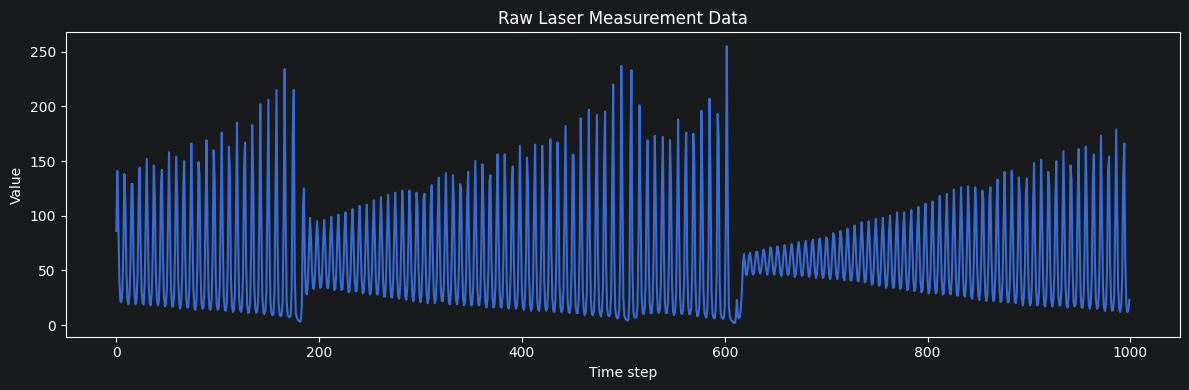

Train: (784, 20), Val: (196, 20)


In [2]:

data = scipy.io.loadmat('../Xtrain.mat')
X = data['Xtrain'].flatten().astype(np.float32)  # shape: (1000,)

print(f"Length: {len(X)}")
print(f"Min: {X.min()}, Max: {X.max()}, Mean: {X.mean():.2f}, Std: {X.std():.2f}")

plt.figure(figsize=(12, 4))
plt.plot(X)
plt.title("Raw Laser Measurement Data")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("raw_data.png")
plt.show()


scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X.reshape(-1, 1)).flatten()


def make_sequences(data, window):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:i+window])
        y_seq.append(data[i+window])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

WINDOW = 20  # tune this in part (b)
X_seq, y_seq = make_sequences(X_scaled, WINDOW)

# Train/val split (80/20)
split = int(len(X_seq) * 0.8)
X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Select your choice of neural networks model that is suitable for this task and motivate it. Train your model to predict one step ahead data point, during training (see following Figure). Scale your data before training and scale them back to be able to compare your predictions with real measurements.

## GRU (Gated Recurrent Unit)

#### Motivation:

The dataset contains 1000 laser measurements. Since the data comes from a physical measurement process, we expect each value to be related to the values that came before it. We also expect the signal to follow some repeating pattern over time, with possible sudden changes in amplitude. For these reasons, a simple model like Linear Regression is not suitable, because it treats each input independently and cannot learn from the order of the data. We propose using a Gated Recurren Unit (GRU) network, which is a type of recurrent neural network designed to work with sequential data. GRU keeps a hidden state that acts as a memory, allowing it to learn patterns across multiple time steps. Compared to a basic RNN, GRU uses gates that help it remember important information over longer periods without losing it during training. Compared to LSTM, GRU has fewer parameters and is less likely to overfit on a dataset this size. For these reasons we believe GRU is a good and well-suited choice for predicting the next value in this sequence

Using device: cpu
Epoch   5/75 | Train MSE: 0.012371 | Val MSE: 0.005451
Epoch  10/75 | Train MSE: 0.005033 | Val MSE: 0.000632
Epoch  15/75 | Train MSE: 0.004656 | Val MSE: 0.000444
Epoch  20/75 | Train MSE: 0.003249 | Val MSE: 0.000560
Epoch  25/75 | Train MSE: 0.002817 | Val MSE: 0.000631
Epoch  30/75 | Train MSE: 0.002193 | Val MSE: 0.000143
Epoch  35/75 | Train MSE: 0.002076 | Val MSE: 0.000216
Epoch  40/75 | Train MSE: 0.001900 | Val MSE: 0.000393
Epoch  45/75 | Train MSE: 0.001708 | Val MSE: 0.000148
Epoch  50/75 | Train MSE: 0.001696 | Val MSE: 0.000239
Epoch  55/75 | Train MSE: 0.001446 | Val MSE: 0.000146
Epoch  60/75 | Train MSE: 0.001416 | Val MSE: 0.000201
Epoch  65/75 | Train MSE: 0.001066 | Val MSE: 0.000096
Epoch  70/75 | Train MSE: 0.001189 | Val MSE: 0.000089
Epoch  75/75 | Train MSE: 0.000796 | Val MSE: 0.000139


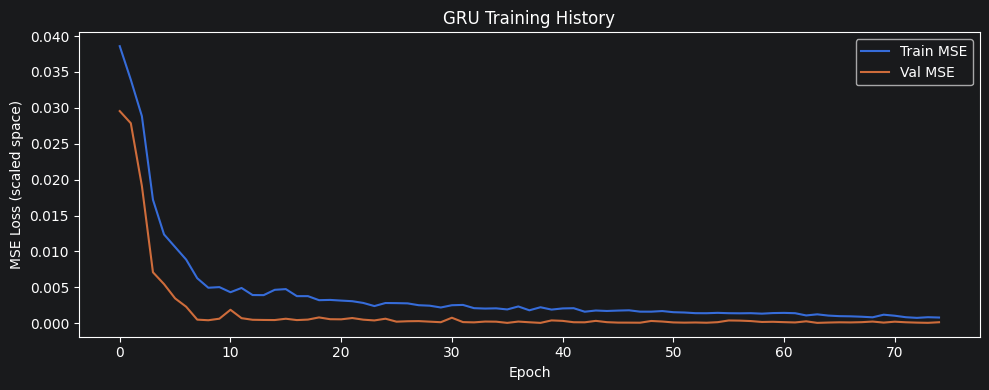

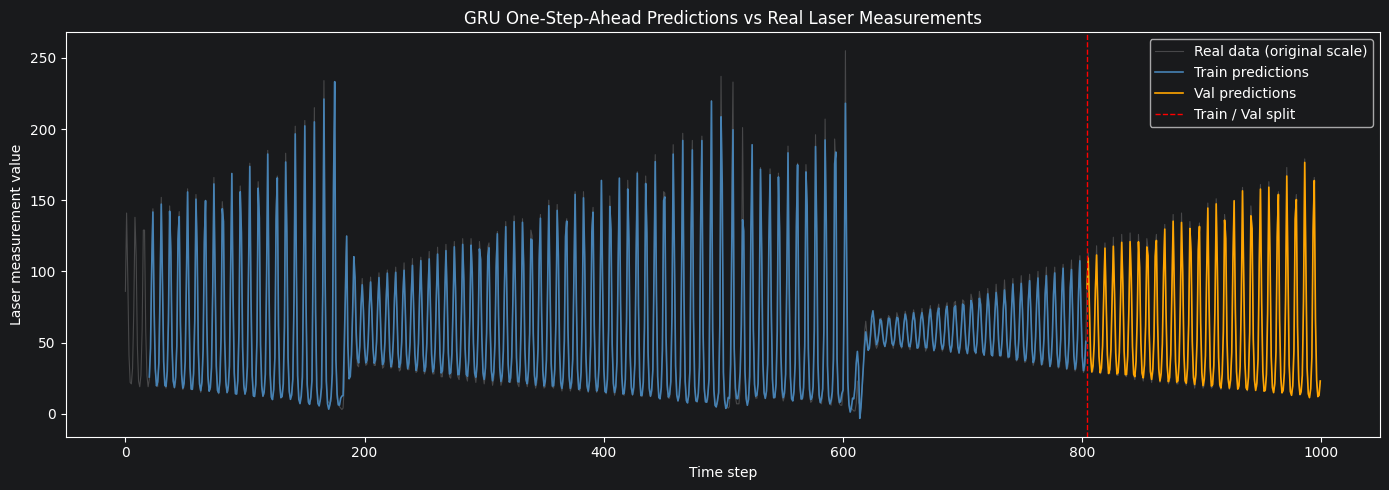

In [3]:

# Hyperparameters
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
EPOCHS = 75
LR = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

# Prepare tensors
X_train_t = torch.tensor(X_train).unsqueeze(-1)
X_val_t   = torch.tensor(X_val).unsqueeze(-1)
y_train_t = torch.tensor(y_train)
y_val_t   = torch.tensor(y_val)

# DataLoaders
train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

# Model, optimizer and loss function
model = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# Training loop
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # Training phase
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(float(np.mean(batch_losses)))

    # Validation phase
    model.eval()
    with torch.no_grad():
        vb_losses = [criterion(model(xb.to(device)), yb.to(device)).item()
                     for xb, yb in val_dl]
    val_losses.append(float(np.mean(vb_losses)))

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train MSE: {train_losses[-1]:.6f} | Val MSE: {val_losses[-1]:.6f}")

# Plot loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train MSE")
ax.plot(val_losses,   label="Val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled space)")
ax.set_title("GRU Training History")
ax.legend()
plt.tight_layout()
plt.show()

# Generate predictions on full sequence and inverse scale back to original range
model.eval()
with torch.no_grad():
    X_all_t   = torch.tensor(X_seq).unsqueeze(-1).to(device)
    y_pred_sc = model(X_all_t).cpu().numpy()

y_pred = scaler.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_seq.reshape(-1, 1)).flatten()

# Align time indices — predictions start at WINDOW because
# the first window X[0:WINDOW] predicts X[WINDOW]
t_all = np.arange(WINDOW, len(X))
t_tr  = t_all[:split]
t_val = t_all[split:]

# Plot predictions vs real measurements
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(X, color="gray", alpha=0.45, linewidth=0.8, label="Real data (original scale)")
ax.plot(t_tr,  y_pred[:split], color="steelblue", linewidth=1.2, label="Train predictions")
ax.plot(t_val, y_pred[split:], color="orange", linewidth=1.2, label="Val predictions")
ax.axvline(t_val[0], color="red", linestyle="--", linewidth=1.0, label="Train / Val split")
ax.set_title("GRU One-Step-Ahead Predictions vs Real Laser Measurements")
ax.set_xlabel("Time step")
ax.set_ylabel("Laser measurement value")
ax.legend()
plt.tight_layout()
plt.show()


Window=  5  best Val MSE=0.000064
Window= 10  best Val MSE=0.000039
Window= 20  best Val MSE=0.000046
Window= 30  best Val MSE=0.000090
Window= 50  best Val MSE=0.000079

✓ Best window size: 10  (Val MSE=0.000039)


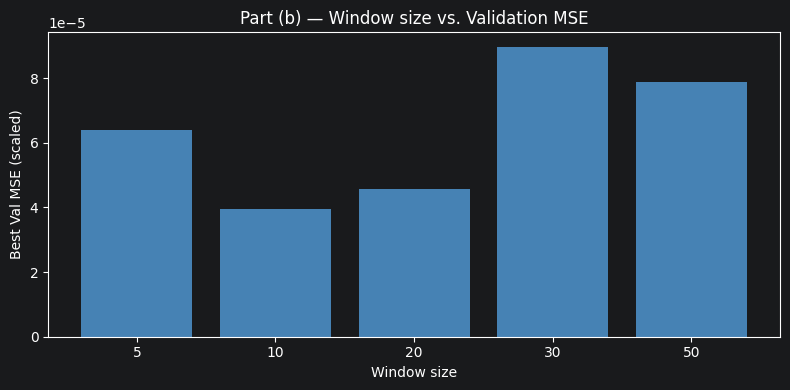

In [4]:
"""
b: window size tuning
"""

# Reload Data
data = scipy.io.loadmat('../Xtrain.mat')
X = data['Xtrain'].flatten().astype(np.float32)
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X.reshape(-1, 1)).flatten()

def make_sequences(data, window):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:i+window])
        y_seq.append(data[i+window])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=0.1 if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# WINDOW SEARCH
WINDOWS   = [5, 10, 20, 30, 50]
EPOCHS    = 75
LR        = 1e-3
results   = {}

for W in WINDOWS:
    X_seq, y_seq = make_sequences(X_scaled, W)
    split = int(len(X_seq) * 0.8)
    X_tr, X_va = X_seq[:split], X_seq[split:]
    y_tr, y_va = y_seq[:split], y_seq[split:]

    tr_dl = DataLoader(TensorDataset(torch.tensor(X_tr).unsqueeze(-1),
                                     torch.tensor(y_tr)),
                       batch_size=32, shuffle=True)
    va_dl = DataLoader(TensorDataset(torch.tensor(X_va).unsqueeze(-1),
                                     torch.tensor(y_va)),
                       batch_size=64, shuffle=False)

    model = GRUModel().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()

    best_val = float('inf')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_mse = np.mean([crit(model(xb.to(device)), yb.to(device)).item()
                               for xb, yb in va_dl])
        if val_mse < best_val:
            best_val = val_mse

    results[W] = best_val
    print(f"Window={W:3d}  best Val MSE={best_val:.6f}")

best_window = min(results, key=results.get)
print(f"\n✓ Best window size: {best_window}  (Val MSE={results[best_window]:.6f})")

# bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(w) for w in WINDOWS], [results[w] for w in WINDOWS], color='steelblue')
ax.set_xlabel("Window size")
ax.set_ylabel("Best Val MSE (scaled)")
ax.set_title("Part (b) — Window size vs. Validation MSE")
plt.tight_layout()
plt.show()

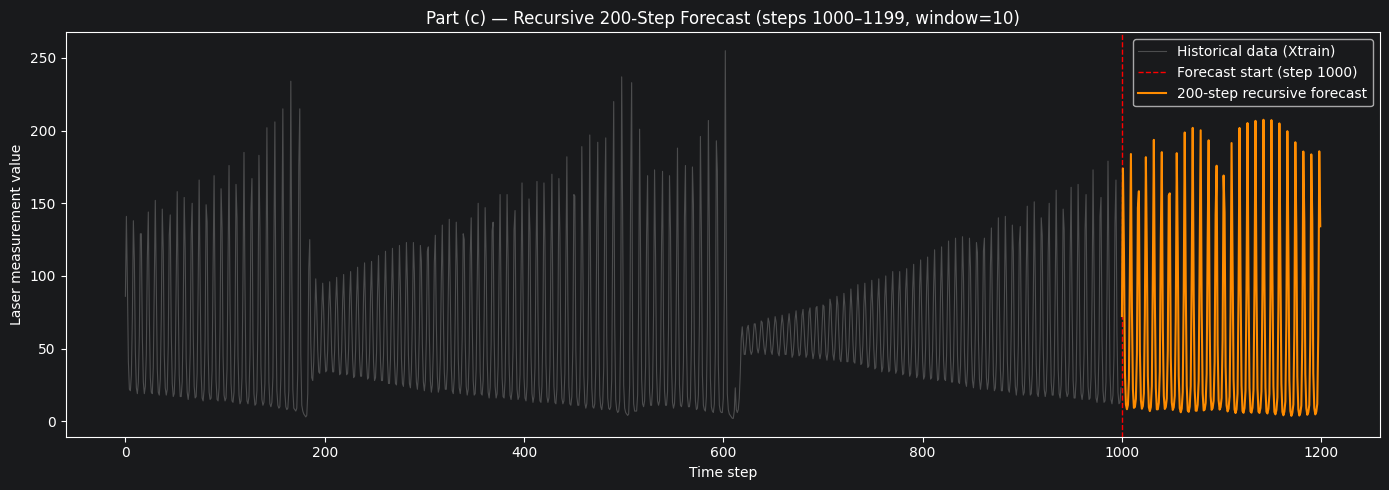

Forecast covers steps 1000 – 1199
Predicted range: [3.7, 207.5]


In [5]:
"""
c: recursive 200-step ahead forecast
"""
# Re-train final model
W = best_window
X_seq, y_seq = make_sequences(X_scaled, W)
split = int(len(X_seq) * 0.8)

X_tr, X_va = X_seq[:split], X_seq[split:]
y_tr, y_va = y_seq[:split], y_seq[split:]

tr_dl = DataLoader(TensorDataset(torch.tensor(X_tr).unsqueeze(-1),
                                 torch.tensor(y_tr)),
                   batch_size=32, shuffle=True)

final_model = GRUModel().to(device)
opt  = torch.optim.Adam(final_model.parameters(), lr=1e-3)
crit = nn.MSELoss()

for epoch in range(1, EPOCHS + 1):
    final_model.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        crit(final_model(xb), yb).backward()
        opt.step()

# Seed: last W points of the ENTIRE Xtrain (steps 1000-W to 1000)
seed = X_scaled[-W:].tolist()

final_model.eval()
recursive_preds_scaled = []

with torch.no_grad():
    window = seed.copy()
    for _ in range(200):
        inp = torch.tensor(window[-W:], dtype=torch.float32)
        inp = inp.unsqueeze(0).unsqueeze(-1).to(device)
        pred = final_model(inp).item()
        recursive_preds_scaled.append(pred)
        window.append(pred)

recursive_preds = scaler.inverse_transform(
    np.array(recursive_preds_scaled).reshape(-1, 1)).flatten()

# Plot: forecast starts at step 1000 (right after Xtrain ends)
t_hist     = np.arange(len(X))
t_forecast = np.arange(len(X), len(X) + 200)  # 1000–1199

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_hist, X, color='gray', alpha=0.5, lw=0.8, label='Historical data (Xtrain)')
ax.axvline(len(X), color='red', linestyle='--', lw=1.0, label='Forecast start (step 1000)')
ax.plot(t_forecast, recursive_preds, color='darkorange', lw=1.5, label='200-step recursive forecast')
ax.set_title(f"Part (c) — Recursive 200-Step Forecast (steps 1000–1199, window={W})")
ax.set_xlabel("Time step")
ax.set_ylabel("Laser measurement value")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Forecast covers steps {t_forecast[0]} – {t_forecast[-1]}")
print(f"Predicted range: [{recursive_preds.min():.1f}, {recursive_preds.max():.1f}]")

In [6]:
#D# — evaluate Part C recursive forecast against Xtest ground truth

test_data = scipy.io.loadmat('/content/Xtest.mat')
X_test = test_data['Xtest'].flatten().astype(np.float32)

print(f"Test set length: {len(X_test)}")

# recursive_preds is already in original scale from Part C (200 values)
# X_test contains the 200 real values we forecast against
assert len(recursive_preds) == len(X_test), \
    f"Length mismatch: {len(recursive_preds)} predictions vs {len(X_test)} test points"

y_pred_test = recursive_preds          # 200 recursive predictions from C
y_true_test = X_test                   # 200 real measurements

# Metrics
mae  = mean_absolute_error(y_true_test, y_pred_test)
mse  = mean_squared_error(y_true_test, y_pred_test)
rmse = np.sqrt(mse)

print(f"\n── Test Set Performance (200-step recursive forecast vs Xtest) ──")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

# Plot
t_test = np.arange(len(X_test))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_test, y_true_test, color='gray', lw=1.0, label='Real Xtest values')
ax.plot(t_test, y_pred_test, color='steelblue', lw=1.2, label='Recursive forecast (from C)')
ax.set_title("Part (d) — Recursive 200-Step Forecast vs Real Xtest")
ax.set_xlabel("Time step (within test set)")
ax.set_ylabel("Laser measurement value")
ax.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Xtest.mat'

In [ ]:
from scipy.io import loadmat
import numpy as np

xtest = loadmat("Xtest.mat")
newxtest = loadmat("newXtest.mat")

key1 = [k for k in xtest if not k.startswith("_")][0]
key2 = [k for k in newxtest if not k.startswith("_")][0]

a = xtest[key1].flatten()
b = newxtest[key2].flatten()

print(f"Xtest shape   : {a.shape}")
print(f"newXtest shape: {b.shape}")
print(f"Same shape    : {a.shape == b.shape}")

if a.shape == b.shape:
    equal = np.array_equal(a, b)
    print(f"Identical     : {equal}")
    if not equal:
        diff = np.abs(a - b)
        print(f"Max diff      : {diff.max():.6f}")
        print(f"Mean diff     : {diff.mean():.6f}")
        print(f"N differing   : {(diff > 0).sum()} / {len(a)}")
else:
    print("Shapes differ — cannot compare element-wise.")